# TT-24 — PCA trên bộ dữ liệu UCI HAR (Human Activity Recognition Using Smartphones)


In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
import time

from pca_pipeline import (
    load_har_data,
    fit_scaler_and_full_pca, bang_nguong_phuong_sai, ve_scree_plot,
    ve_phuong_sai_tich_luy, thi_nghiem_danh_doi_K, tim_diem_ngot, ve_danh_doi_K,
    ve_scatter_pc1_pc2, phan_tich_pc1, do_dung_luong, sai_so_tai_tao_theo_K,
    K_LIST,
)
from pathlib import Path

%matplotlib inline

## Bước 1: Nạp dữ liệu (giữ nguyên chia theo người)

In [2]:
DATA_DIR = "../dataset/UCI HAR Dataset"

d = load_har_data(DATA_DIR)
X_train, y_train, y_train_name = d["X_train"], d["y_train"], d["y_train_name"]
X_test, y_test = d["X_test"], d["y_test"]
feature_names = d["feature_names"]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Số người train:", d["subject_train"].nunique(), "| test:", d["subject_test"].nunique())
X_train.head()

X_train: (7352, 561) | X_test: (2947, 561)
Số người train: 21 | test: 9


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


## Bước 2-3: Chuẩn hoá (fit CHỈ trên train) + PCA đầy đủ

In [3]:
scaler, pca_full, X_train_s = fit_scaler_and_full_pca(X_train)
X_test_s = scaler.transform(X_test)
print("Số thành phần chính tối đa:", pca_full.n_components_)

Số thành phần chính tối đa: 561


## Bước 3: Scree plot — phương sai từng thành phần

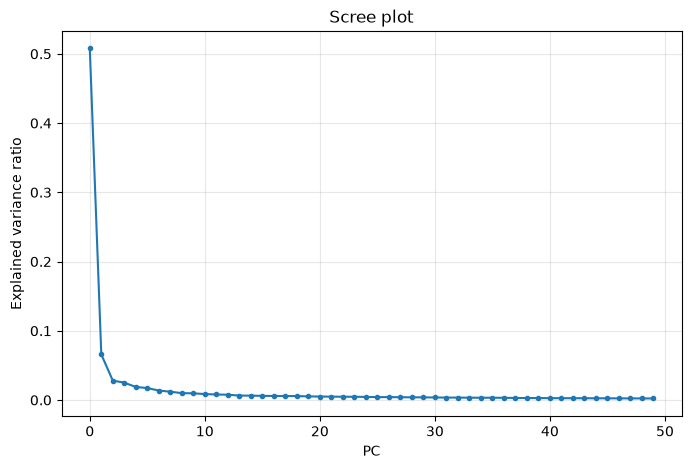

In [4]:
ve_scree_plot(pca_full, Path("../reports/scree_plot.png"))
plt.figure(figsize=(8,5))
plt.plot(pca_full.explained_variance_ratio_[:50], marker='o', markersize=3)
plt.xlabel("PC"); plt.ylabel("Explained variance ratio"); plt.title("Scree plot")
plt.grid(alpha=0.3); plt.show()

## Bước 4-5: Phương sai tích luỹ + bảng ngưỡng

In [5]:
ve_phuong_sai_tich_luy(pca_full, Path("../reports/variance_tich_luy.png"))

bang_nguong = bang_nguong_phuong_sai(pca_full, X_train.shape[1])
bang_nguong

,nguong_phuong_sai,so_chieu_can,phan_tram_giam_chieu
0,80%,26,95.4%
1,90%,63,88.8%
2,95%,102,81.8%
3,99%,179,68.1%


## Bước 6 (Thí nghiệm chính): Đánh đổi số chiều K vs Accuracy

Với mỗi K trong {2, 10, 25, 50, 100, 200, 561}, huấn luyện `LinearSVC` trên dữ liệu
đã giảm chiều và đo accuracy + thời gian train trên tập test.


In [6]:
df_ketqua = thi_nghiem_danh_doi_K(
    X_train_s, y_train.values.ravel(), X_test_s, y_test.values.ravel(), K_LIST
)
df_ketqua

  K=   2 | accuracy=0.5772 | thời gian train=0.09s
  K=  10 | accuracy=0.8331 | thời gian train=0.13s
  K=  25 | accuracy=0.8921 | thời gian train=0.17s
  K=  50 | accuracy=0.9118 | thời gian train=0.37s
  K= 100 | accuracy=0.9315 | thời gian train=0.50s
  K= 200 | accuracy=0.9515 | thời gian train=2.40s
  K= 561 | accuracy=0.9617 | thời gian train=13.51s


,K,accuracy,thoi_gian_train_s
0,2,0.577197,0.088761
1,10,0.833051,0.128692
2,25,0.892094,0.167877
3,50,0.911775,0.369893
4,100,0.931456,0.502367
5,200,0.951476,2.396514
6,561,0.961656,13.514383


In [7]:
diem_ngot = tim_diem_ngot(df_ketqua)
print(f"Điểm ngọt: K = {diem_ngot} (accuracy giảm < 1% so với dùng đủ 561 chiều)")

ve_danh_doi_K(df_ketqua, diem_ngot, Path("../reports/danh_doi_chieu_accuracy.png"))

Điểm ngọt: K = 561 (accuracy giảm < 1% so với dùng đủ 561 chiều)


## Bước 7: Scatter PC1–PC2 tô màu theo 6 hoạt động

In [8]:
pca2 = ve_scatter_pc1_pc2(X_train_s, y_train_name, Path("../reports/pc1_pc2_scatter.png"))

## Bước 8: Phân tích ý nghĩa PC1

Xem 10 đặc trưng gốc đóng góp nhiều nhất (trọng số |w| lớn nhất) vào PC1,
để trả lời câu hỏi: PC1 đại diện cho khái niệm vật lý gì?


In [9]:
df_pc1 = phan_tich_pc1(pca_full, feature_names, top_n=10)
df_pc1

,dac_trung_goc,trong_so_PC1
0,fBodyAcc-sma(),0.058571
1,fBodyAccJerk-sma(),0.058568
2,tBodyAccJerk-sma(),0.058538
3,fBodyGyro-sma(),0.058531
4,tBodyAccJerkMag-mean(),0.058493
5,tBodyAccJerkMag-sma(),0.058493
6,fBodyBodyAccJerkMag-sma(),0.058128
7,fBodyBodyAccJerkMag-mean(),0.058128
8,tBodyAccJerkMag-mad(),0.058017
9,tBodyAccJerkMag-std(),0.057985


## Bước 9: Đo dung lượng — dữ liệu gốc vs sau PCA (tại điểm ngọt)

In [10]:
dung_luong = do_dung_luong(X_train, diem_ngot)
dung_luong

{'dung_luong_goc_MB': np.float64(33.0),
 'dung_luong_sau_pca_MB': 33.0,
 'phan_tram_tiet_kiem': '0.0%'}

## Bước 10: Tái tạo ngược (inverse_transform) — sai số theo K

In [11]:
df_tai_tao = sai_so_tai_tao_theo_K(
    X_test_s, X_train_s, sorted(set([2, 10, 25, 50, diem_ngot, 100, 200])),
    Path("../reports/reconstruction_error.png"),
)
df_tai_tao

,K,mse_tai_tao
0,2,0.391686
1,10,0.288043
2,25,0.204893
3,50,0.132448
4,100,0.057836
5,200,0.008047


## Bước 11: So sánh nhanh với SelectKBest


In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

skb = SelectKBest(score_func=f_classif, k=diem_ngot).fit(X_train_s, y_train.values.ravel())
X_train_skb = skb.transform(X_train_s)
X_test_skb = skb.transform(X_test_s)

clf = LinearSVC(max_iter=5000, random_state=42).fit(X_train_skb, y_train.values.ravel())
acc_skb = clf.score(X_test_skb, y_test.values.ravel())

acc_pca_tuong_duong = df_ketqua.loc[df_ketqua['K'] == diem_ngot, 'accuracy']
print(f"SelectKBest (k={diem_ngot}) accuracy: {acc_skb:.4f}")
print(f"PCA (k={diem_ngot}) accuracy       : {float(acc_pca_tuong_duong.iloc[0]):.4f}")

SelectKBest (k=561) accuracy: 0.9627
PCA (k=561) accuracy       : 0.9617


## Lưu pipeline cuối cùng

In [13]:
final_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA(n_components=diem_ngot, random_state=42)),
    ('clf', LinearSVC(max_iter=5000, random_state=42)),
])
final_pipe.fit(X_train, y_train.values.ravel())
acc_final = final_pipe.score(X_test, y_test.values.ravel())

import joblib
joblib.dump(final_pipe, "../models/pca_pipeline.joblib")
print(f"Đã lưu models/pca_pipeline.joblib | accuracy trên test = {acc_final:.4f}")

Đã lưu models/pca_pipeline.joblib | accuracy trên test = 0.9617
